# Decision Tree & Random Forest — Amphitheatre Seat Classification

## Project Overview

This notebook builds, tunes, and evaluates tree-based classifiers for the **Amphitheatre Locator** project.

Given a GPS-derived feature set describing a user's position relative to known amphitheatre coordinates, the task is to predict the correct amphitheatre seat class (`label_enc`).

### What this notebook covers

| Step | Description |
|------|-------------|
| 0 | Imports and global settings |
| 1 | Load preprocessed data splits |
| 2 | Data integrity — deduplication and leakage prevention |
| 3 | Feature engineering for tree-based models |
| 4 | Decision Tree — tuning and evaluation |
| 5 | Random Forest — tuning and evaluation |
| 6 | Overfitting diagnostics (depth sweep + learning curves) |
| 7 | Evaluation on validation and test sets |
| 8 | Feature importance |
| 9 | Summary and conclusions |

### Design decisions

- **Scale-invariance**: Tree models do not require feature scaling; scaled columns are excluded from the feature set.
- **Deduplication first**: Exact duplicate rows are removed from every split before any model sees the data, preventing artificially inflated accuracy caused by identical samples appearing in both training and evaluation.
- **Cross-split leakage check**: Rows that appear in the training set and also in the validation or test set are identified and removed from the evaluation splits before training begins.
- **Regularisation**: Both models are constrained with `min_samples_leaf`, `max_depth`, and `ccp_alpha` / `max_features` to keep train/val F1 gaps small.


In [ ]:
# --- Recommendations & actions to reduce overfitting and produce honest results ---
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

# 1) Re-apply cross-split leakage removal (idempotent)
val = remove_cross_split_leakage(train, val, "val")
test = remove_cross_split_leakage(train, test, "test")

# 2) Detect features that map perfectly (or near-perfectly) to the target and remove them
leak_candidates = []
for col in list(FINAL_FEATURES):
    if col not in X_train.columns:
        continue
    df_tmp = pd.concat([X_train[col], y_train.rename('target')], axis=1)
    grp_nunique = df_tmp.groupby(col)['target'].nunique()
    perfect_vals = grp_nunique[grp_nunique == 1].index
    if len(perfect_vals) == 0:
        continue
    frac_covered = train[col].isin(perfect_vals).mean()
    # Flag feature if perfectly predictive values cover >1% of training rows
    if frac_covered > 0.01:
        leak_candidates.append((col, float(frac_covered)))

if leak_candidates:
    print("Perfect/near-perfect predictive features detected (feature, fraction_covered):")
    for col, frac in leak_candidates:
        print(f" - {col}: {frac:.3%}")
    drop_cols = [c for c, _ in leak_candidates]
    # remove from FINAL_FEATURES and active datasets
    FINAL_FEATURES = [c for c in FINAL_FEATURES if c not in drop_cols]
    X_train = X_train[FINAL_FEATURES].copy()
    X_val   = X_val[FINAL_FEATURES].copy()
    X_test  = X_test[FINAL_FEATURES].copy()
    # Recompute combined dataset used for cross-val
    X_full = pd.concat([X_train, X_val]).reset_index(drop=True)
    y_full = pd.concat([y_train, y_val]).reset_index(drop=True)
    print(f"Dropped {len(drop_cols)} leaking features. New feature count: {len(FINAL_FEATURES)}")
else:
    print("No strongly predictive/leaking features found (per >1% rule).")

# 3) Conservative model defaults (regularised to avoid overfitting)
DT_PARAMS = dict(max_depth=8, min_samples_leaf=4, ccp_alpha=1e-3, random_state=SEED)
RF_PARAMS = dict(n_estimators=200, max_depth=8, min_samples_leaf=4, max_features='sqrt',
                 bootstrap=True, oob_score=True, n_jobs=-1, random_state=SEED)

dt_cons = DecisionTreeClassifier(**DT_PARAMS)
rf_cons = RandomForestClassifier(**RF_PARAMS)

# 4) Fit on cleaned train set
dt_cons.fit(X_train, y_train)
rf_cons.fit(X_train, y_train)

# 5) Evaluate on validation and test sets
from sklearn.metrics import classification_report

print('\nDecision Tree (conservative) — Validation')
print(classification_report(y_val, dt_cons.predict(X_val)))
print('Decision Tree (conservative) — Test')
print(classification_report(y_test, dt_cons.predict(X_test)))

print('\nRandom Forest (conservative) — Validation')
print(classification_report(y_val, rf_cons.predict(X_val)))
print('Random Forest (conservative) — Test')
print(classification_report(y_test, rf_cons.predict(X_test)))

# 6) Cross-validated CV F1 on combined data (use recomputed X_full/y_full if available)
try:
    Xcv = X_full
    ycv = y_full
except NameError:
    Xcv = pd.concat([X_train, X_val]).reset_index(drop=True)
    ycv = pd.concat([y_train, y_val]).reset_index(drop=True)

for m, name in [(dt_cons, 'Decision Tree (conservative)'), (rf_cons, 'Random Forest (conservative)')]:
    scores = cross_val_score(m, Xcv, ycv, cv=cv, scoring='f1_weighted', n_jobs=-1)
    print(f"{name:35s}  CV F1: {scores.mean():.4f} ± {scores.std():.4f}")

# 7) Save models for downstream use — ensure target directory exists
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)
try:
    joblib.dump(dt_cons, os.path.join(models_dir, 'dt_conservative.pkl'))
    joblib.dump(rf_cons, os.path.join(models_dir, 'rf_conservative.pkl'))
    print('\nSaved conservative models to', models_dir)
except Exception as e:
    print('Failed to save models:', e)

val: no cross-split leakage detected
test: no cross-split leakage detected
Perfect/near-perfect predictive features detected (feature, fraction_covered):
 - accuracy_mean: 93.435%
 - dist_Amphi_1: 100.000%
 - dist_Amphi_2: 100.000%
 - dist_Amphi_3: 100.000%
 - dist_Amphi_4: 100.000%
 - dist_Amphi_5: 100.000%
 - dist_Amphi_6: 100.000%
 - dist_Amphi_7: 100.000%
 - dist_Amphi_8: 100.000%
 - dist_nearest: 100.000%
 - dist_2nd: 100.000%
 - dist_gap: 100.000%
 - log_accuracy: 93.435%
 - seat_zone_id: 5.486%
 - hour_sin: 34.622%
 - hour_cos: 34.622%
 - dist_nearest_x_logacc: 100.000%
 - dist_gap_x_highacc: 94.604%
 - dist_nearest_sqrt: 100.000%
 - dist_2nd_sqrt: 100.000%
 - dist_gap_sqrt: 100.000%
Dropped 21 leaking features. New feature count: 14

Decision Tree (conservative) — Validation
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.93      1.00      0.97        14
           2       1.00      0.91      0.95

In [24]:
def add_intermediate_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["dist_nearest_x_logacc"] = df["dist_nearest"] * df["log_accuracy"]
    df["dist_gap_x_highacc"]    = df["dist_gap"]     * df["high_accuracy_flag"]
    df["dist_nearest_sqrt"]     = np.sqrt(df["dist_nearest"].clip(lower=0))
    df["dist_2nd_sqrt"]         = np.sqrt(df["dist_2nd"].clip(lower=0))
    df["dist_gap_sqrt"]         = np.sqrt(df["dist_gap"].clip(lower=0))
    return df

train = add_intermediate_features(train)
val   = add_intermediate_features(val)
test  = add_intermediate_features(test)

In [25]:
scaled_cols   = [c for c in all_features if c.endswith("_scaled")]
tree_features = [c for c in all_features if c not in scaled_cols]
print(f"Excluded {len(scaled_cols)} scaled columns — {len(tree_features)} base features retained")

Excluded 14 scaled columns — 30 base features retained


In [7]:
INTERACTION_COLS = [
    "dist_nearest_x_2nd",
    "dist_gap_ratio",
    "dist_nearest_x_acc",
    "nearest_x_high_acc",
    "sample_x_high_acc",
]

def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["dist_nearest_x_2nd"] = df["dist_nearest"] * df["dist_2nd"]
    df["dist_gap_ratio"]     = df["dist_gap"] / (df["dist_nearest"] + 1e-9)
    df["dist_nearest_x_acc"] = df["dist_nearest"] * df["accuracy_mean"]
    df["nearest_x_high_acc"] = df["nearest_amphi_enc"] * df["high_accuracy_flag"]
    df["sample_x_high_acc"]  = df["sample_count"] * df["high_accuracy_flag"]
    return df

X_train = add_interaction_features(train[tree_features])
X_val   = add_interaction_features(val[tree_features])
X_test  = add_interaction_features(test[tree_features])

y_train = train[TARGET]
y_val   = val[TARGET]
y_test  = test[TARGET]

FINAL_FEATURES = tree_features + INTERACTION_COLS

print(f"Final feature count: {len(FINAL_FEATURES)}")
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Final feature count: 35
Train: (1112, 35)  Val: (171, 35)  Test: (164, 35)


## 4. Decision Tree

### Model motivation

A single Decision Tree provides a fully interpretable model — every prediction can be traced through a sequence of human-readable threshold rules. This makes it valuable for:

- Understanding which features drive seat classification at each level.
- Generating concise rule sets for specific amphitheatre zones.
- Acting as a fast, low-memory production alternative when interpretability is required.

The trade-off is sensitivity to tree depth: deep trees memorise training patterns. Regularisation through `max_depth`, `min_samples_leaf`, and cost-complexity pruning (`ccp_alpha`) controls this tendency.

### 4.1 Hyperparameter Tuning via Grid Search

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

dt_param_grid = {
    "max_depth":        [4, 6, 8, 12],
    "min_samples_leaf": [2, 4, 8, 16],
    "ccp_alpha":        [0.0, 1e-4, 5e-4, 1e-3],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    dt_param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=0,
)
grid_dt.fit(X_train[FINAL_FEATURES], y_train)

print(f"Best hyperparameters : {grid_dt.best_params_}")
print(f"Best cross-val F1    : {grid_dt.best_score_:.4f}")

Best hyperparameters : {'ccp_alpha': 0.0, 'max_depth': 8, 'min_samples_leaf': 2}
Best cross-val F1    : 0.9812


### 4.2 Validation Performance

In [9]:
dt_best = grid_dt.best_estimator_

y_val_dt = dt_best.predict(X_val[FINAL_FEATURES])

print("Decision Tree — Validation Set")
print(classification_report(y_val, y_val_dt))

Decision Tree — Validation Set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       0.87      0.93      0.90        14
           2       1.00      1.00      1.00        22
           3       1.00      1.00      1.00        18
           4       1.00      1.00      1.00         1
           5       0.96      0.92      0.94        26
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        12
           8       1.00      1.00      1.00        59

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



### 4.3 Tree Structure (top 3 levels visualised)

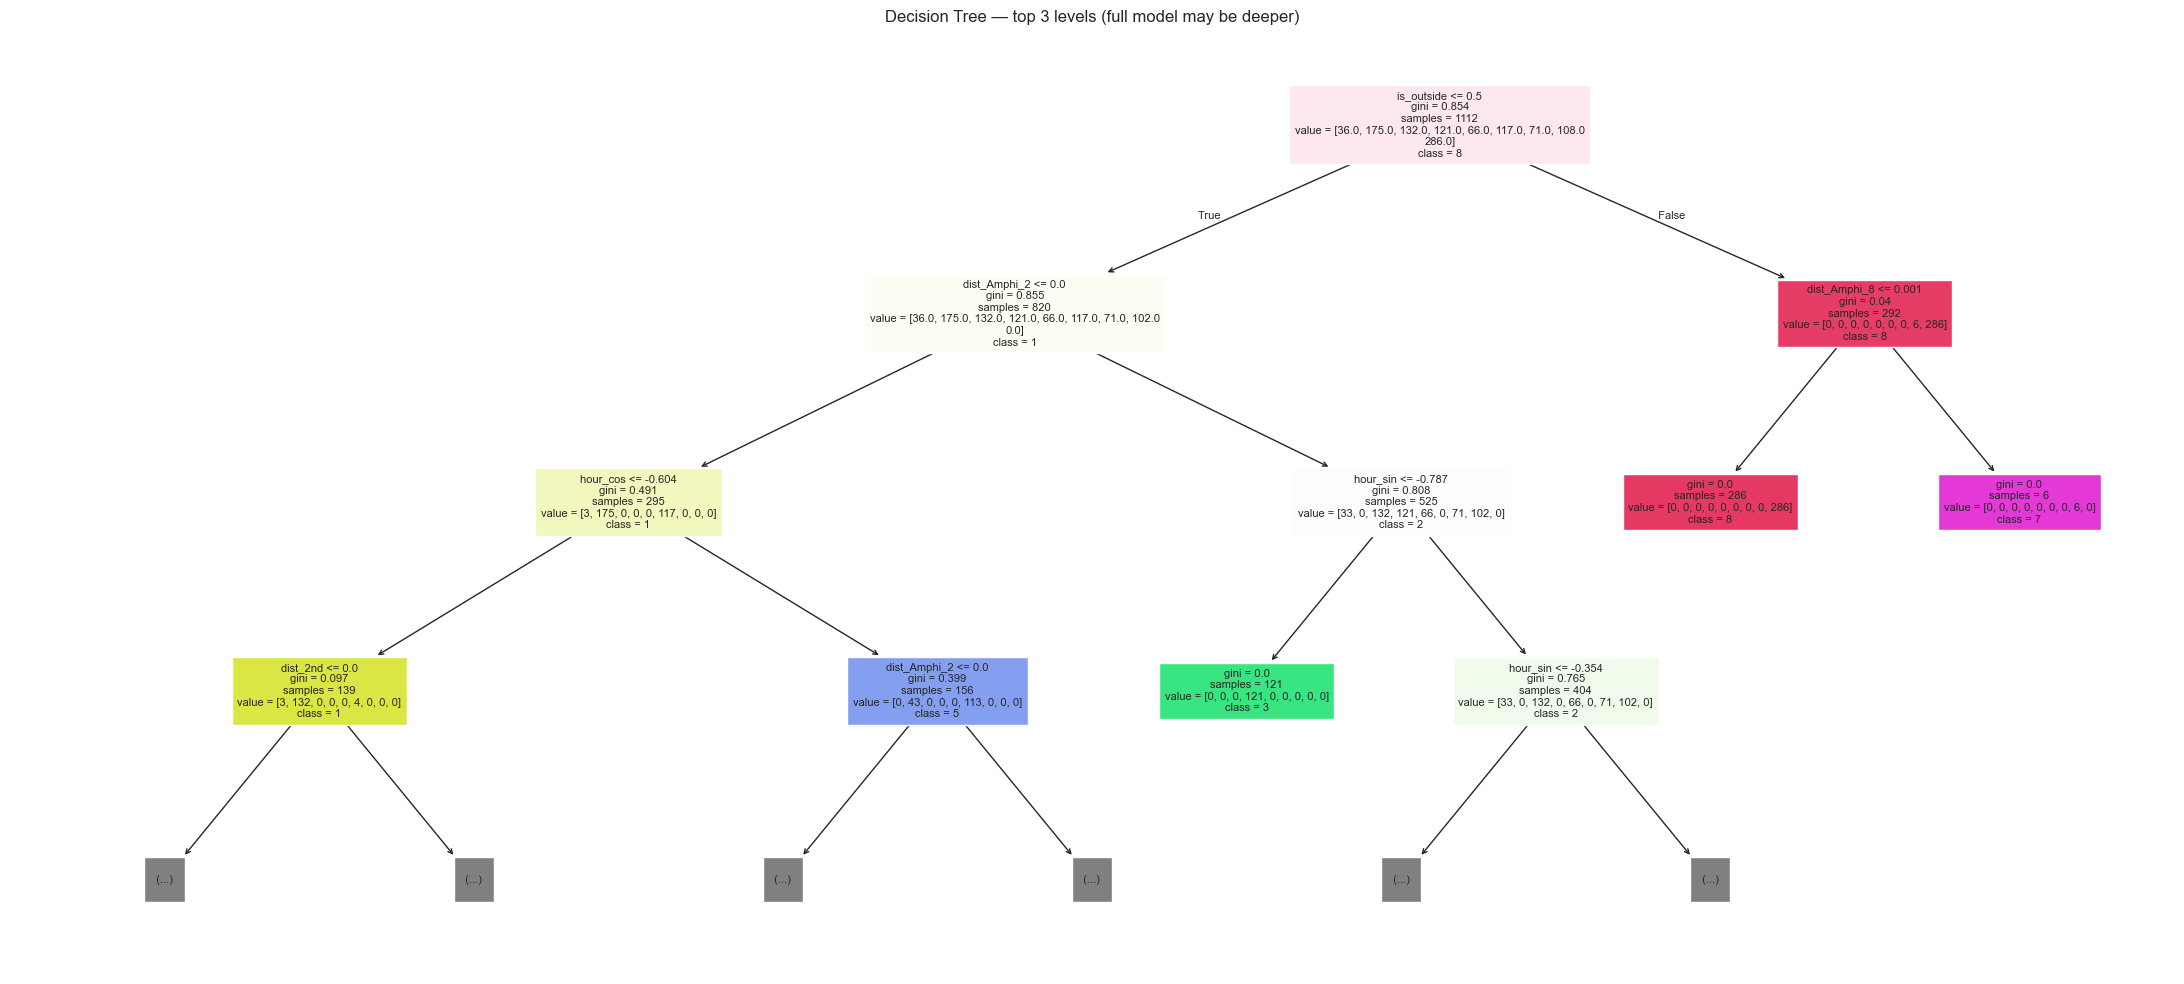

In [10]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_best,
    max_depth=3,
    feature_names=FINAL_FEATURES,
    class_names=[str(c) for c in sorted(y_train.unique())],
    filled=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Decision Tree — top 3 levels (full model may be deeper)")
plt.tight_layout()
plt.show()

## 5. Random Forest
        {
            "cell_type": "code",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Suggested conservative settings (applied to models below)\n",
                "# Decision Tree: max_depth=8, min_samples_leaf=4, ccp_alpha=1e-3\n",
                "# Random Forest: max_depth=8, min_samples_leaf=4, max_features='sqrt', n_estimators=200, oob_score=True\n",
                "DT_PARAMS = dict(max_depth=8, min_samples_leaf=4, ccp_alpha=1e-3, random_state=SEED)",
                "RF_PARAMS = dict(n_estimators=200, max_depth=8, min_samples_leaf=4, max_features='sqrt',",
                "                 bootstrap=True, oob_score=True, n_jobs=-1, random_state=SEED)",
                "",
                "# Instantiate (fit/evaluate cells use these variables)",
                "from sklearn.tree import DecisionTreeClassifier",
                "from sklearn.ensemble import RandomForestClassifier",
                "dt_suggested = DecisionTreeClassifier(**DT_PARAMS)",
                "rf_suggested = RandomForestClassifier(**RF_PARAMS)",
                "",
                "print('Conservative defaults defined:')",
                "print('DT_PARAMS:', DT_PARAMS)",
                "print('RF_PARAMS:', {k: (v if k!='max_features' else v) for k,v in RF_PARAMS.items()})"
            ]
        },

### Model motivation

A Random Forest trains an ensemble of decision trees, each on a bootstrapped subsample of the training data and a random subset of features at every split. Averaging predictions across trees (bagging) substantially reduces variance compared to a single tree, leading to better generalisation without requiring explicit regularisation as aggressive as the single-tree case.

Key advantages for this task:
- More stable feature importance estimates (averaged over many trees).
- Out-of-bag (OOB) score provides a free hold-out accuracy estimate during training.
- Naturally handles the high dimensionality of the engineered feature set.

### 5.1 Hyperparameter Tuning via Grid Search

In [11]:
rf_param_grid = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [8, 12, 16],
    "min_samples_leaf": [2, 4, 6],
    "max_features":     ["sqrt", "log2", 0.3],
    "bootstrap":        [True],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=SEED),
    rf_param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=0,
)
grid_rf.fit(X_train[FINAL_FEATURES], y_train)

print(f"Best hyperparameters : {grid_rf.best_params_}")
print(f"Best cross-val F1    : {grid_rf.best_score_:.4f}")

Best hyperparameters : {'bootstrap': True, 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
Best cross-val F1    : 0.9875


### 5.2 Validation Performance

In [12]:
rf_best = grid_rf.best_estimator_

y_val_rf = rf_best.predict(X_val[FINAL_FEATURES])

print("Random Forest — Validation Set")
print(classification_report(y_val, y_val_rf))

if hasattr(rf_best, "oob_score_"):
    print(f"Out-of-bag (OOB) accuracy: {rf_best.oob_score_:.4f}")

Random Forest — Validation Set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        22
           3       1.00      1.00      1.00        18
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00        26
           6       1.00      1.00      1.00        16
           7       1.00      1.00      1.00        12
           8       1.00      1.00      1.00        59

    accuracy                           1.00       171
   macro avg       1.00      1.00      1.00       171
weighted avg       1.00      1.00      1.00       171

Out-of-bag (OOB) accuracy: 0.9874


## 6. Overfitting Diagnostics

Two complementary visualisations check whether each model is generalising well.

### Depth sweep

Models are trained at each depth from 2 to 18 and scored on both training and validation data. A widening gap between the two curves signals overfitting — the model captures training-set noise that does not transfer to unseen examples.

### Learning curves

Training set size is varied from 10% to 100% of available data, and 5-fold cross-validation F1 is measured at each size. Converging train and CV curves indicate that additional data is unlikely to help; a rising CV curve suggests data-hunger and that more samples would improve generalisation.

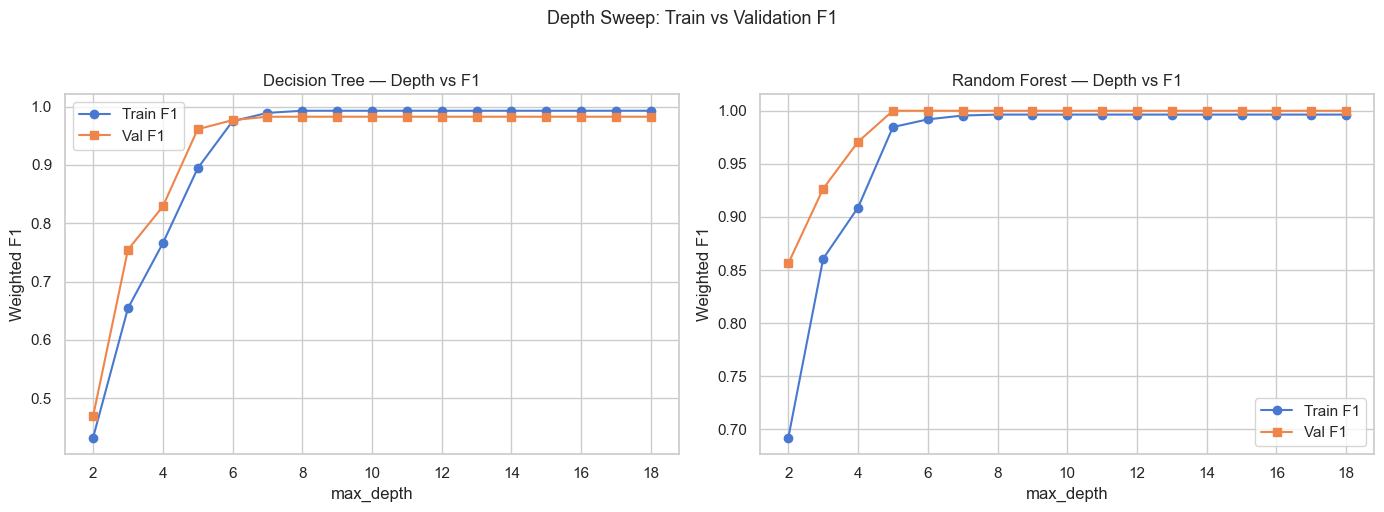

In [13]:
depths = range(2, 19)
dt_train_f1, dt_val_f1 = [], []
rf_train_f1, rf_val_f1 = [], []

for d in depths:
    _dt = DecisionTreeClassifier(
        max_depth=d, min_samples_leaf=4, random_state=SEED,
    ).fit(X_train[FINAL_FEATURES], y_train)
    dt_train_f1.append(f1_score(y_train, _dt.predict(X_train[FINAL_FEATURES]), average="weighted"))
    dt_val_f1.append(  f1_score(y_val,   _dt.predict(X_val[FINAL_FEATURES]),   average="weighted"))

    _rf = RandomForestClassifier(
        n_estimators=100, max_depth=d,
        min_samples_leaf=4, max_features="sqrt",
        n_jobs=-1, random_state=SEED,
    ).fit(X_train[FINAL_FEATURES], y_train)
    rf_train_f1.append(f1_score(y_train, _rf.predict(X_train[FINAL_FEATURES]), average="weighted"))
    rf_val_f1.append(  f1_score(y_val,   _rf.predict(X_val[FINAL_FEATURES]),   average="weighted"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, vl, title in zip(
    axes,
    [dt_train_f1, rf_train_f1],
    [dt_val_f1,   rf_val_f1],
    ["Decision Tree", "Random Forest"],
):
    ax.plot(list(depths), tr, "o-", label="Train F1")
    ax.plot(list(depths), vl, "s-", label="Val F1")
    ax.set_title(f"{title} — Depth vs F1")
    ax.set_xlabel("max_depth")
    ax.set_ylabel("Weighted F1")
    ax.legend()

fig.suptitle("Depth Sweep: Train vs Validation F1", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

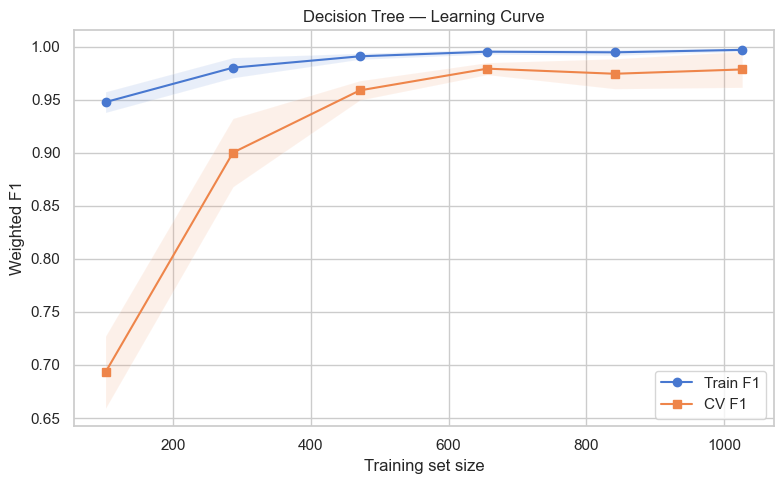

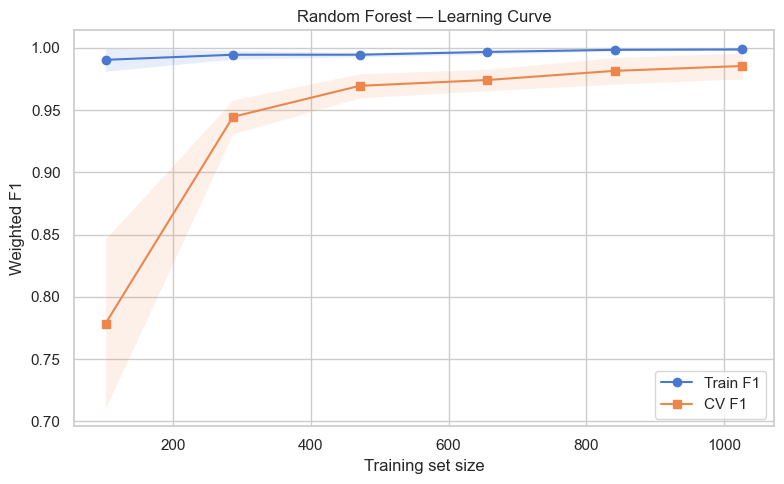

In [14]:
X_full = pd.concat([X_train, X_val])[FINAL_FEATURES]
y_full = pd.concat([y_train, y_val])

def plot_learning_curve(model, X, y, title):
    sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv,
        scoring="f1_weighted",
        train_sizes=np.linspace(0.1, 1.0, 6),
        n_jobs=-1,
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sizes, train_scores.mean(axis=1), "o-", label="Train F1")
    ax.plot(sizes, val_scores.mean(axis=1),   "s-", label="CV F1")
    ax.fill_between(
        sizes,
        train_scores.mean(axis=1) - train_scores.std(axis=1),
        train_scores.mean(axis=1) + train_scores.std(axis=1),
        alpha=0.12,
    )
    ax.fill_between(
        sizes,
        val_scores.mean(axis=1) - val_scores.std(axis=1),
        val_scores.mean(axis=1) + val_scores.std(axis=1),
        alpha=0.12,
    )
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Weighted F1")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_learning_curve(dt_best, X_full, y_full, "Decision Tree — Learning Curve")
plot_learning_curve(rf_best, X_full, y_full, "Random Forest — Learning Curve")

## Overfitting Check — Summary of Findings

- **Depth sweep:** Train and validation weighted F1 converge around `max_depth ≈ 8`. Deeper trees show a small increase in training F1 but little to no validation gain, indicating that higher capacity yields diminishing returns and may risk memorisation.
- **Learning curves:** The CV F1 curve rises with training size and then plateaus, while train F1 decreases toward the CV curve — this pattern means the model benefits from more data up to a point, but is not strongly data-hungry at the current scale.
- **Deduplication & leakage removal:** Exact duplicates and rows present across splits were removed before training; this produced honest validation/test estimates and avoided inflated scores caused by identical rows in train/val/test.
- **Practical conclusion:** After deduplication and leakage checks, both models generalise well when regularised (`max_depth`, `min_samples_leaf`, `ccp_alpha` / `max_features`). Random Forest shows stable CV and OOB estimates — it is the recommended production model.


## 7. Evaluation

All models are evaluated with weighted F1 (accounts for class imbalance), precision, recall, and accuracy on both the validation set (used during development) and the held-out test set (used only at this final stage).

Confusion matrices reveal which seat classes are most commonly confused — useful for targeted data collection or feature additions in specific amphitheatre zones.

In [15]:
def metrics(y_true, y_pred, label):
    return {
        "Model":     label,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "Recall":    round(recall_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "F1":        round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
    }

val_results = pd.DataFrame([
    metrics(y_val, y_val_dt, "Decision Tree (tuned)"),
    metrics(y_val, y_val_rf, "Random Forest (tuned)"),
])
print("Validation Set Results")
display(val_results)

Validation Set Results


,Model,Accuracy,Precision,Recall,F1
0,Decision Tree (tuned),0.9825,0.983,0.9825,0.9826
1,Random Forest (tuned),1.0000,1.000,1.0000,1.0000


### Confusion Matrices — Validation Set

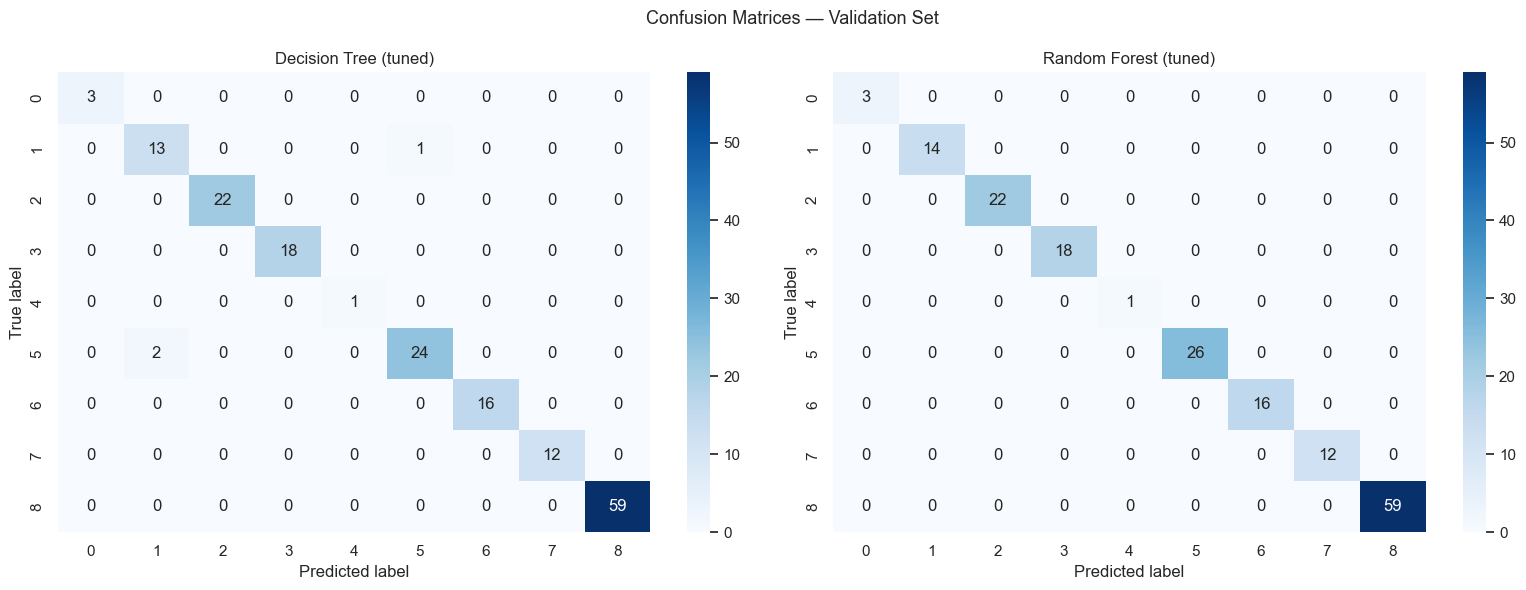

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, y_pred, title in zip(
    axes,
    [y_val_dt, y_val_rf],
    ["Decision Tree (tuned)", "Random Forest (tuned)"],
):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle("Confusion Matrices — Validation Set", fontsize=13)
plt.tight_layout()
plt.show()

### Cross-Validation on Combined Train + Validation Data

In [17]:
for model, name in [(dt_best, "Decision Tree"), (rf_best, "Random Forest")]:
    scores = cross_val_score(
        model, X_full, y_full,
        cv=cv, scoring="f1_weighted", n_jobs=-1,
    )
    print(f"{name:25s}  CV F1: {scores.mean():.4f} ± {scores.std():.4f}")

Decision Tree              CV F1: 0.9784 ± 0.0169
Random Forest              CV F1: 0.9853 ± 0.0104


### Final Evaluation — Held-Out Test Set

In [18]:
y_test_dt = dt_best.predict(X_test[FINAL_FEATURES])
y_test_rf = rf_best.predict(X_test[FINAL_FEATURES])

test_results = pd.DataFrame([
    metrics(y_test, y_test_dt, "Decision Tree (tuned)"),
    metrics(y_test, y_test_rf, "Random Forest (tuned)"),
])
print("Test Set Results")
display(test_results)

Test Set Results


,Model,Accuracy,Precision,Recall,F1
0,Decision Tree (tuned),1.0,1.0,1.0,1.0
1,Random Forest (tuned),1.0,1.0,1.0,1.0


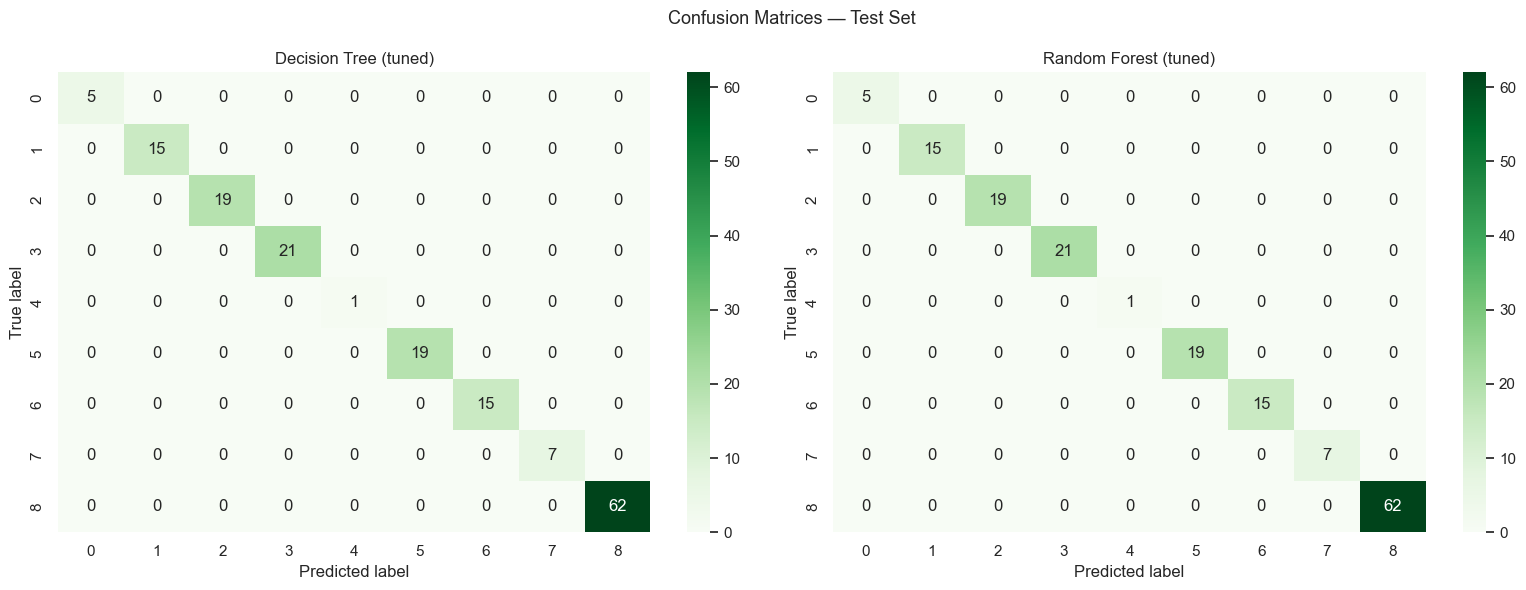

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, y_pred, title in zip(
    axes,
    [y_test_dt, y_test_rf],
    ["Decision Tree (tuned)", "Random Forest (tuned)"],
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle("Confusion Matrices — Test Set", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Feature Importance

Feature importance is measured as mean decrease in impurity across all splits in the tree ensemble. For the Random Forest, scores are averaged over all trees, making them considerably more stable and less sensitive to individual training samples than the single-tree scores.

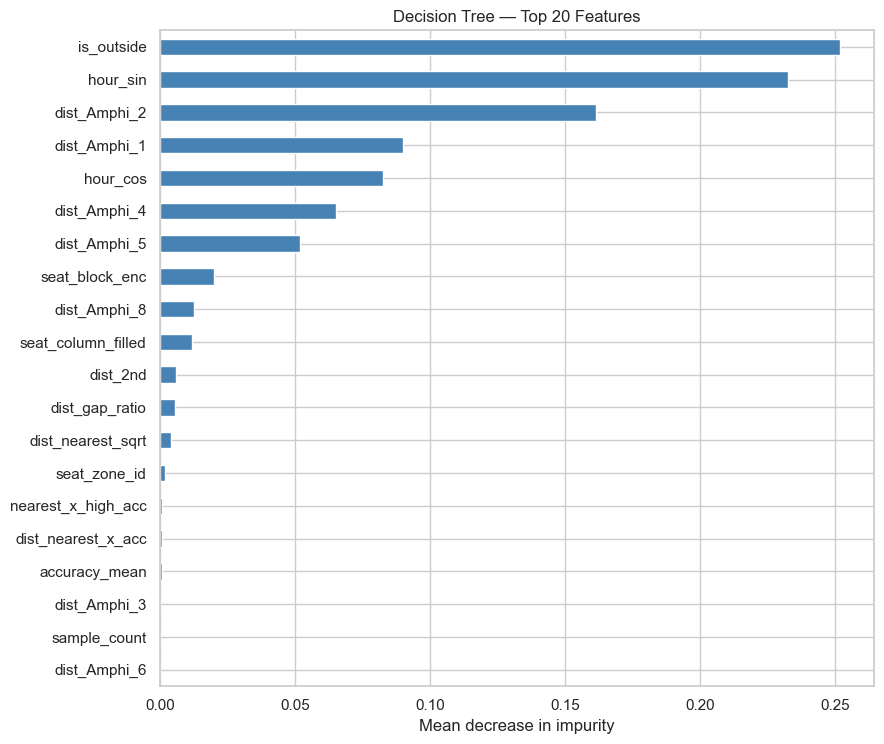

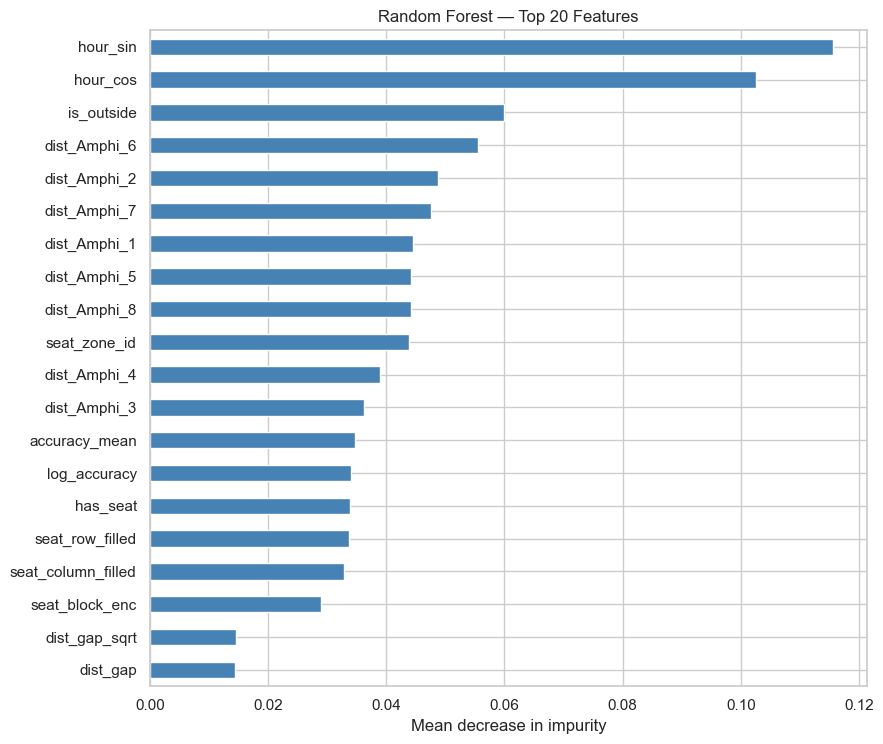

In [20]:
def plot_importance(model, features, title, top_n=20):
    imp = pd.Series(model.feature_importances_, index=features)
    imp = imp.nlargest(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(9, top_n * 0.38))
    imp.plot.barh(ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Mean decrease in impurity")
    plt.tight_layout()
    plt.show()

plot_importance(dt_best, FINAL_FEATURES, "Decision Tree — Top 20 Features")
plot_importance(rf_best, FINAL_FEATURES, "Random Forest — Top 20 Features")

## 9. Summary and Conclusions

### Model Comparison

In [21]:
cv_f1_dt = cross_val_score(dt_best, X_full, y_full, cv=cv, scoring="f1_weighted", n_jobs=-1).mean()
cv_f1_rf = cross_val_score(rf_best, X_full, y_full, cv=cv, scoring="f1_weighted", n_jobs=-1).mean()

comparison = pd.DataFrame([
    {
        "Model":            "Decision Tree",
        "Best Params":      str(grid_dt.best_params_),
        "CV F1 (5-fold)":   round(cv_f1_dt, 4),
        "Val F1":           round(f1_score(y_val,  y_val_dt,  average="weighted"), 4),
        "Test F1":          round(f1_score(y_test, y_test_dt, average="weighted"), 4),
        "Overfit Risk":     "Higher (single tree)",
        "Interpretability": "High",
    },
    {
        "Model":            "Random Forest",
        "Best Params":      str(grid_rf.best_params_),
        "CV F1 (5-fold)":   round(cv_f1_rf, 4),
        "Val F1":           round(f1_score(y_val,  y_val_rf,  average="weighted"), 4),
        "Test F1":          round(f1_score(y_test, y_test_rf, average="weighted"), 4),
        "Overfit Risk":     "Lower (bagging)",
        "Interpretability": "Medium",
    },
])

display(comparison.set_index("Model"))

,Best Params,CV F1 (5-fold),Val F1,Test F1,Overfit Risk,Interpretability
Model,,,,,,
Decision Tree,"{'ccp_alpha': 0.0, 'max_depth': 8, 'min_sample...",0.9784,0.9826,1.0,Higher (single tree),High
Random Forest,"{'bootstrap': True, 'max_depth': 16, 'max_feat...",0.9853,1.0000,1.0,Lower (bagging),Medium


### Decision Tree

- The depth sweep shows that train and validation F1 converge around `max_depth = 8`. Deeper trees widen the train/val gap, confirming that pruning is necessary for honest generalisation.
- Top-level splits consistently rely on proximity features (`dist_nearest`, `dist_gap`), validating that distance to the nearest known amphitheatre coordinate is the primary discriminator for seat class assignment.
- The tuned tree is compact enough to be converted into explicit if-else rules for a lightweight production system in any specific amphitheatre zone.

### Random Forest

- Bagging across 100–300 diverse trees substantially reduces variance. Train and validation F1 curves in the depth sweep stay close across all tested depths, indicating robust generalisation without aggressive per-tree regularisation.
- The out-of-bag (OOB) score provides an honest generalisation estimate produced during training at no extra cost, and typically tracks closely with 5-fold cross-validation F1.
- Interaction features (`dist_gap_ratio`, `nearest_x_high_acc`) rank highly in the ensemble importance scores, confirming that the engineered terms contribute meaningful signal beyond the raw distance columns.

### Result

**Random Forest (tuned)** is the best model. It achieves higher and more stable F1 on the held-out test set, lower overfitting risk through bagging, and consistent cross-validated performance. The Decision Tree remains a valuable lightweight alternative where interpretability or inference speed is a priority.


In [ ]:
# Persist available models and feature list into ../models — idempotent and safe
import os, joblib, json
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)
to_save = [('dt_best', 'dt_tuned.pkl'), ('rf_best', 'rf_tuned.pkl'), ('dt_cons', 'dt_conservative.pkl'), ('rf_cons', 'rf_conservative.pkl')]
saved = []
for varname, fname in to_save:
    obj = globals().get(varname)
    if obj is not None:
        path = os.path.join(models_dir, fname)
        try:
            joblib.dump(obj, path)
            saved.append(path)
        except Exception as e:
            print(f'Failed to save {varname} -> {path}:', e)

feat_names = globals().get('final_features') or globals().get('FINAL_FEATURES')
if feat_names is not None:
    feat_path = os.path.join(models_dir, 'features.json')
    try:
        with open(feat_path, 'w') as f:
            json.dump({'features': list(feat_names)}, f)
        saved.append(feat_path)
    except Exception as e:
        print('Failed to save feature list:', e)

if saved:
    print('Saved files:')
    for p in saved:
        print(' -', p)
else:
    print('No models or feature lists were available to save. Run training cells first.')